In [7]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
!/opt/homebrew/anaconda3/envs/longchain_envllm/bin/python -m pip install kagglehub

In [9]:
import kagglehub
print("kagglehub imported successfully")

kagglehub imported successfully


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/chakradharabhinaymocherla/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2


In [16]:
df = pd.read_csv('/Users/chakradharabhinaymocherla/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2/heart.csv')

print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [18]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
df.info()

Dataset shape: 1025 rows x 14 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [20]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


observation: most have ok fbs but 14% have high fbs; majority have high chols i.e 75% have<=275 but 25% have above 275
total dataset count 1025; mean age around 54 with min age 29 and max 77;upper quartile bbeing around 61 and lower quartile is around 48 and IQR is 56;male dominated as it's mean is 0.7; cp:mean is 0.9 with range being 0-3;resting bp 94-200mm hg mean being 131.6 which is above 120mmhg slight hypertension indication;75% is 140mmhg which is actuallly stage 1 high bp

In [22]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [26]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


Target variable distribution (Heart Disease):
target
1    526
0    499
Name: count, dtype: int64

Proportions:
target
1    0.5132
0    0.4868
Name: proportion, dtype: float64


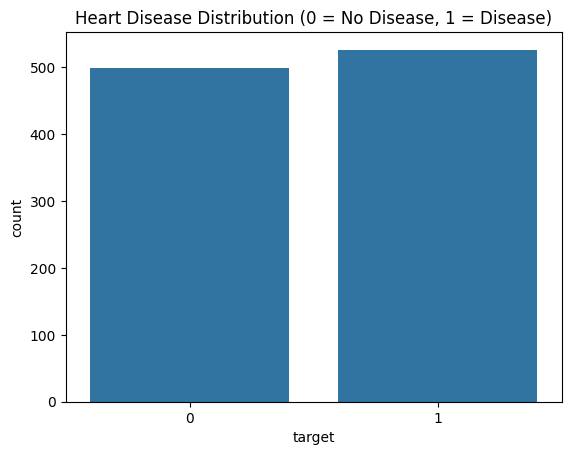

In [32]:
# Target variable distribution
print("Target variable distribution (Heart Disease):")
print(df['target'].value_counts())

print("\nProportions:")
print(df['target'].value_counts(normalize=True).round(4))

# Optional visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution (0 = No Disease, 1 = Disease)")
plt.show()

insights from the above cell? not a class imbalance problem ...equal data on both sides;can depend on accuracy
Observation: The target classes (Member and Normal) are roughly balanced (~50/50), so we do not need to worry about class imbalance techniques.

# feature-wise distribution by target

In [48]:



df['target_label'] = df['target'].map({0: 'No Disease', 1: 'Disease'})

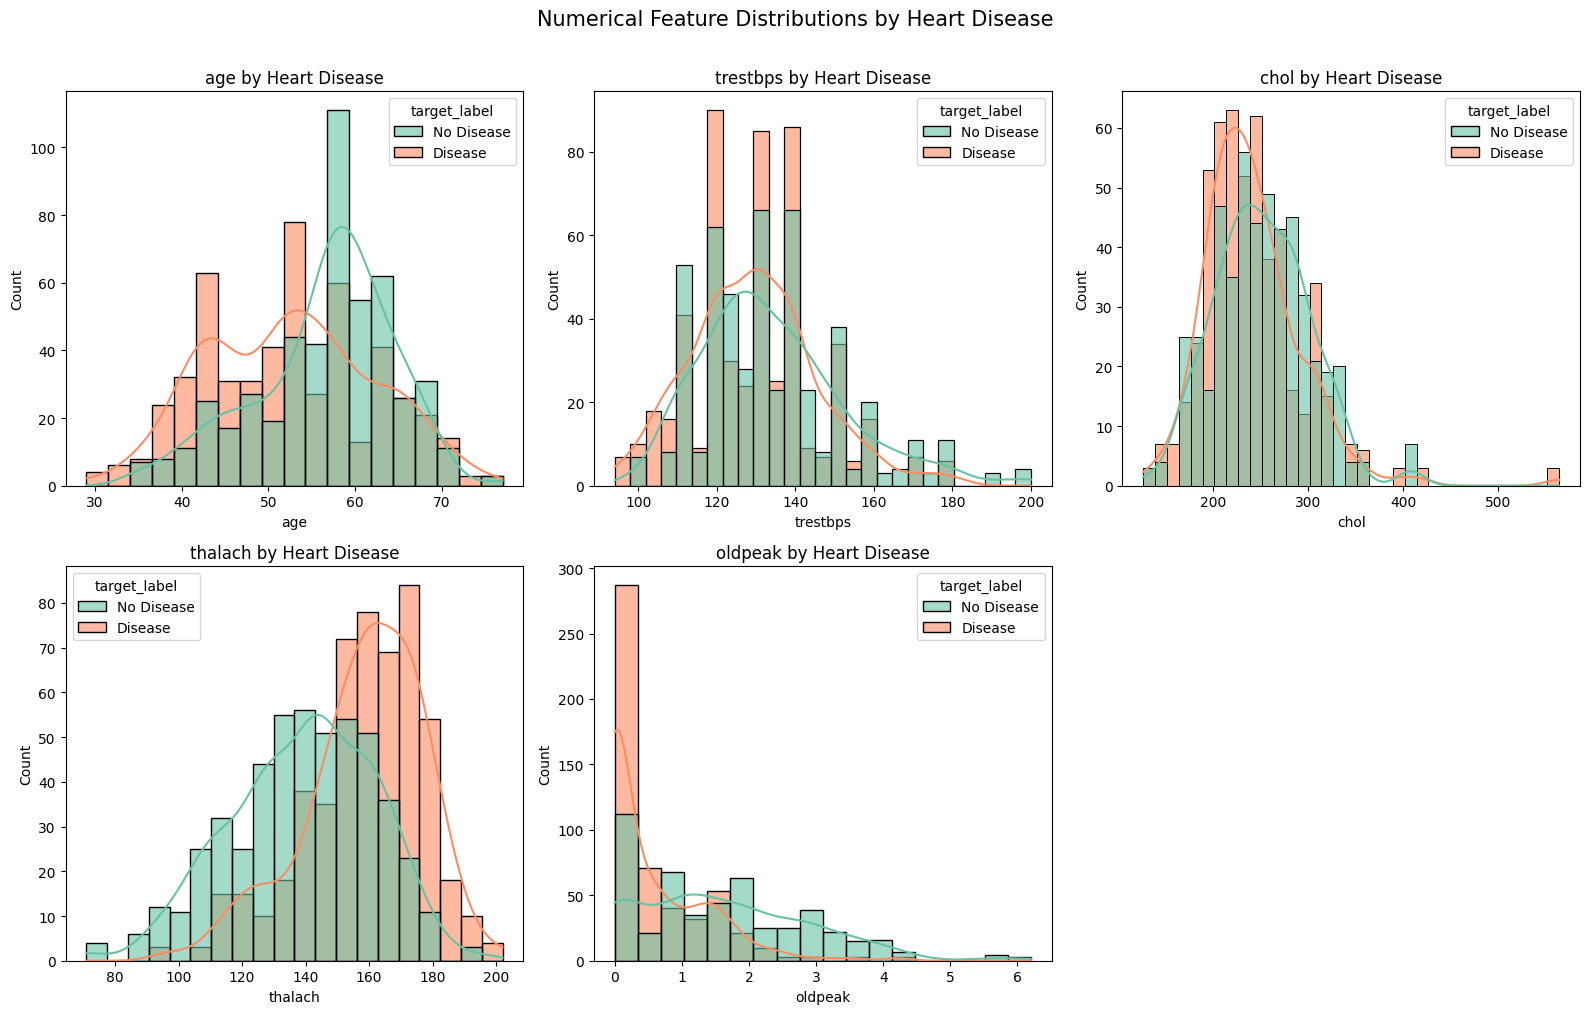

In [57]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df, x=col, hue='target_label',  
        kde=True, palette='Set2', ax=axes[i], alpha=0.6
    )
    axes[i].set_title(f'{col} by Heart Disease', fontsize=12)

axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Heart Disease', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

This visualization shows how numerical features such as age, cholesterol, and heart rate are distributed across patients with and without heart disease. It helps identify patterns and differences between the two groups

Higher oldpeak → often linked to heart disease; Lower thalach (max heart rate) → may indicate risk; Cholesterol & BP distributions help identify trends

# categorical vs target analysis

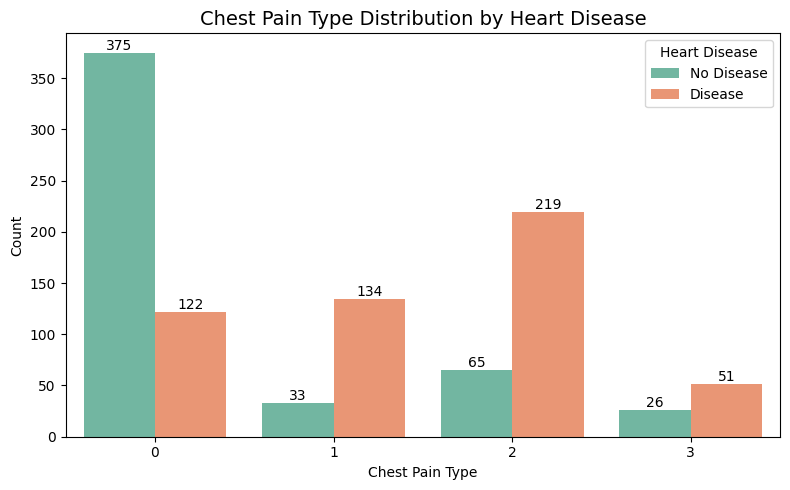

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(x='cp', hue='target_label', data=df, palette='Set2', ax=ax)

ax.set_title('Chest Pain Type Distribution by Heart Disease', fontsize=14)
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
ax.legend(title='Heart Disease')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

<Axes: xlabel='thal', ylabel='count'>

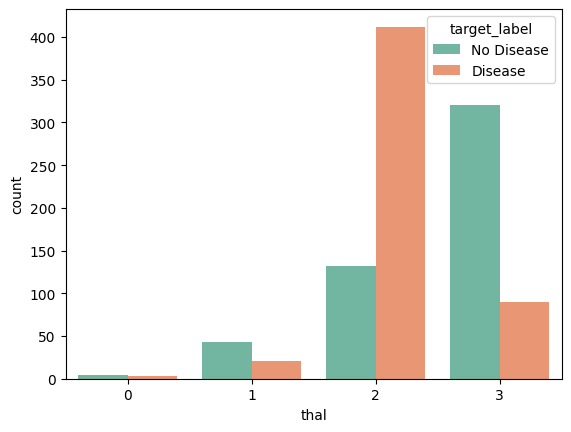

In [72]:
sns.countplot(x='thal', hue='target_label', data=df, palette='Set2')
#⃣ Thal (very important medically)

<Axes: xlabel='exang', ylabel='count'>

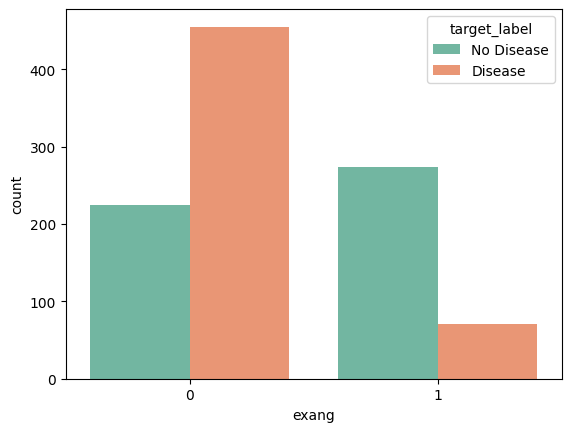

In [74]:
sns.countplot(x='exang', hue='target_label', data=df, palette='Set2')
# Exercise Induced Angina

<Axes: xlabel='sex', ylabel='count'>

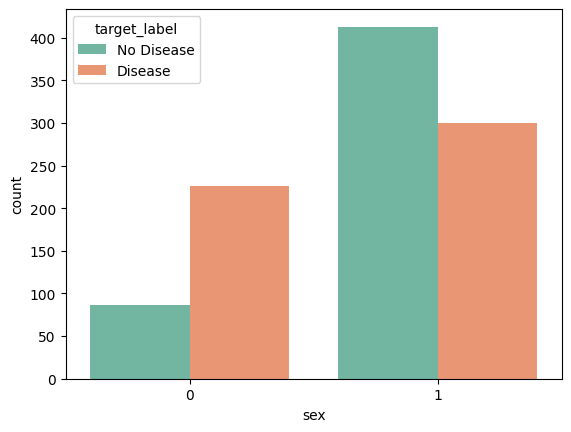

In [80]:
sns.countplot(x='sex', hue='target_label', data=df, palette='Set2')
#gender based

| Value | Type of Chest Pain | Meaning                              |
| ----- | ------------------ | ------------------------------------ |
| 0     | Typical Angina     | Classic heart-related chest pain     |
| 1     | Atypical Angina    | Not classic, but still heart-related |
| 2     | Non-anginal Pain   | Chest pain NOT related to heart      |
| 3     | Asymptomatic       | No chest pain                        |


    Simple explanation 
Typical Angina (0)
→ Strong indicator of heart disease ;
Atypical Angina (1)
→ Possible heart issue;
Non-anginal (2)
→ Usually not heart-related;
Asymptomatic (3)
→ No pain, but disease can still exis;

Chest pain type is a significant indicator of heart disease. Patients with typical angina are more likely to have heart disease, while asymptomatic cases highlight the importance of early detection even without visible symptoms.

Asymptomatic patients may still have heart disease, making this a critical feature for predictive modeling

# Feature Engineering

In [92]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 70, 100],
    labels=['Young', 'Middle Age', 'Senior', 'Elder']
)

In [94]:
df['chol_level'] = pd.cut(
    df['chol'],
    bins=[0, 200, 240, 600],
    labels=['Normal', 'Borderline', 'High']
)

In [96]:
df['bp_level'] = pd.cut(
    df['trestbps'],
    bins=[0, 120, 140, 200],
    labels=['Normal', 'Elevated', 'High']
)

In [98]:
df['hr_level'] = pd.cut(
    df['thalach'],
    bins=[0, 100, 150, 220],
    labels=['Low', 'Normal', 'High']
)

In [100]:
print("New features created:")
print(df[['age', 'age_group', 'chol', 'chol_level']].head(10))

New features created:
   age   age_group  chol  chol_level
0   52  Middle Age   212  Borderline
1   53  Middle Age   203  Borderline
2   70      Senior   174      Normal
3   61      Senior   203  Borderline
4   62      Senior   294        High
5   58      Senior   248        High
6   58      Senior   318        High
7   55  Middle Age   289        High
8   46  Middle Age   249        High
9   54  Middle Age   286        High


Each feature represents a clinically relevant measurement, so removing columns may lead to loss of important predictive information
im not removing anything

# Encoding one hot encoding

In [104]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df['target_label'])

print("Label mapping:")
for label, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {label} -> {encoded}")

print()
print(df['target_encoded'].value_counts())

Label mapping:
  Disease -> 0
  No Disease -> 1

target_encoded
0    526
1    499
Name: count, dtype: int64


Since the dataset is already numerically encoded, additional label encoding is not required. Only human-readable categorical labels are optionally encoded when needed

Machine learning algorithms require features (X) and labels (y) separately.
Without this separation, models cannot learn the relationship between features and the target.

In [108]:
# Features and target
X = df.drop(columns=['target'])  # all medical features
y = df['target']                 # heart disease label

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (1025, 19)
Target shape:   (1025,)


In [110]:
# Check if there are any categorical object columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")  # Should be []

# Feature matrix stays the same
print(f"\nFeature matrix shape: {X.shape}")
print(f"\nColumns:")
print(X.columns.tolist())

Categorical columns to encode: ['target_label']

Feature matrix shape: (1025, 19)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target_label', 'age_group', 'chol_level', 'bp_level', 'hr_level', 'target_encoded']


These columns are already coded numerically in the dataset
don’t need to do anything;
sex, cp, fbs, restecg, exang, slope, ca, thal → already coded as 0/1/2/3

In [113]:
from sklearn.model_selection import train_test_split

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print sizes
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples\n")

# Check target distribution
print("Target distribution in training set:")
print(y_train.value_counts(), "\n")

print("Target distribution in test set:")
print(y_test.value_counts())

Training set: 820 samples
Test set:     205 samples

Target distribution in training set:
target
1    421
0    399
Name: count, dtype: int64 

Target distribution in test set:
target
1    105
0    100
Name: count, dtype: int64


### stratify=y is very important for heart dataset because it avoids imbalance in disease vs no disease in train/test sets.
Typical split: 80% train, 20% test, as we have here.
After this,  X_train and X_test are ready for scaling and modeling.

In [117]:
print("Proportion of classes:")
print(y_train.value_counts(normalize=True).round(2))
print(y_test.value_counts(normalize=True).round(2))

Proportion of classes:
target
1    0.51
0    0.49
Name: proportion, dtype: float64
target
1    0.51
0    0.49
Name: proportion, dtype: float64


models won’t be biased toward one class;51%no disease and 49%disease;

# Normalization

In [153]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define the feature columns for heart disease
feature_cols = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
    'restecg', 'thalach', 'exang', 'oldpeak', 
    'slope', 'ca', 'thal'
]

# Features (X) and target (y)
X = df[feature_cols]  # numeric features only
y = df['target']      # 0 = No Disease, 1 = Disease

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Check shapes
print("Feature scaling complete.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape:     {X_test_scaled.shape}")

Feature scaling complete.
Scaled training data shape: (820, 13)
Scaled test data shape:     (205, 13)


# Evaluation

In [158]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):
    """Predict on test set and print evaluation metrics for heart disease dataset."""
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print()

    # Classification report
    target_names = ['No Disease', 'Disease']
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Return metrics as dictionary
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

# Example usage
results = []
print("Helper function for heart disease evaluation defined.")

Helper function for heart disease evaluation defined.


# Model 1 Logistic regression

=== Logistic Regression ===
Accuracy:  0.8098
Precision: 0.7619
Recall:    0.9143
F1 Score:  0.8312

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.70      0.78       100
     Disease       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



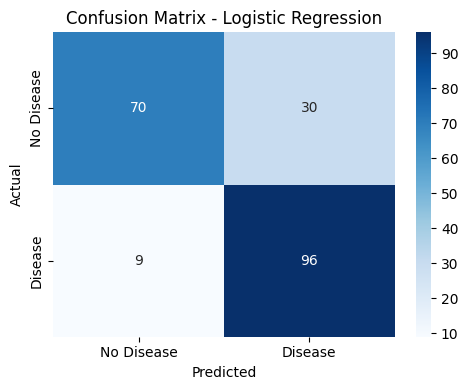

In [161]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Fit model on scaled training data
lr_model.fit(X_train_scaled, y_train)

#  Evaluate model on test set using helper function
lr_results = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression')

# Store results for comparison with other models
results = []
results.append(lr_results)

# Model 2 - decision tree

=== Decision Tree ===
Accuracy:  0.9854
Precision: 1.0000
Recall:    0.9714
F1 Score:  0.9855

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.97      1.00      0.99       100
     Disease       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



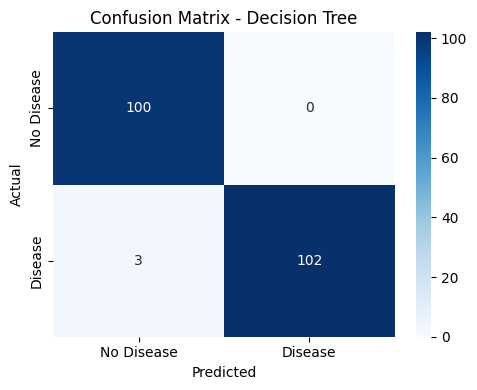

In [164]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

#  Fit the model on scaled training data
dt_model.fit(X_train_scaled, y_train)

# Evaluate on test data using the helper function
dt_results = evaluate_model(dt_model, X_test_scaled, y_test, 'Decision Tree')

# Append results for comparison
results.append(dt_results)

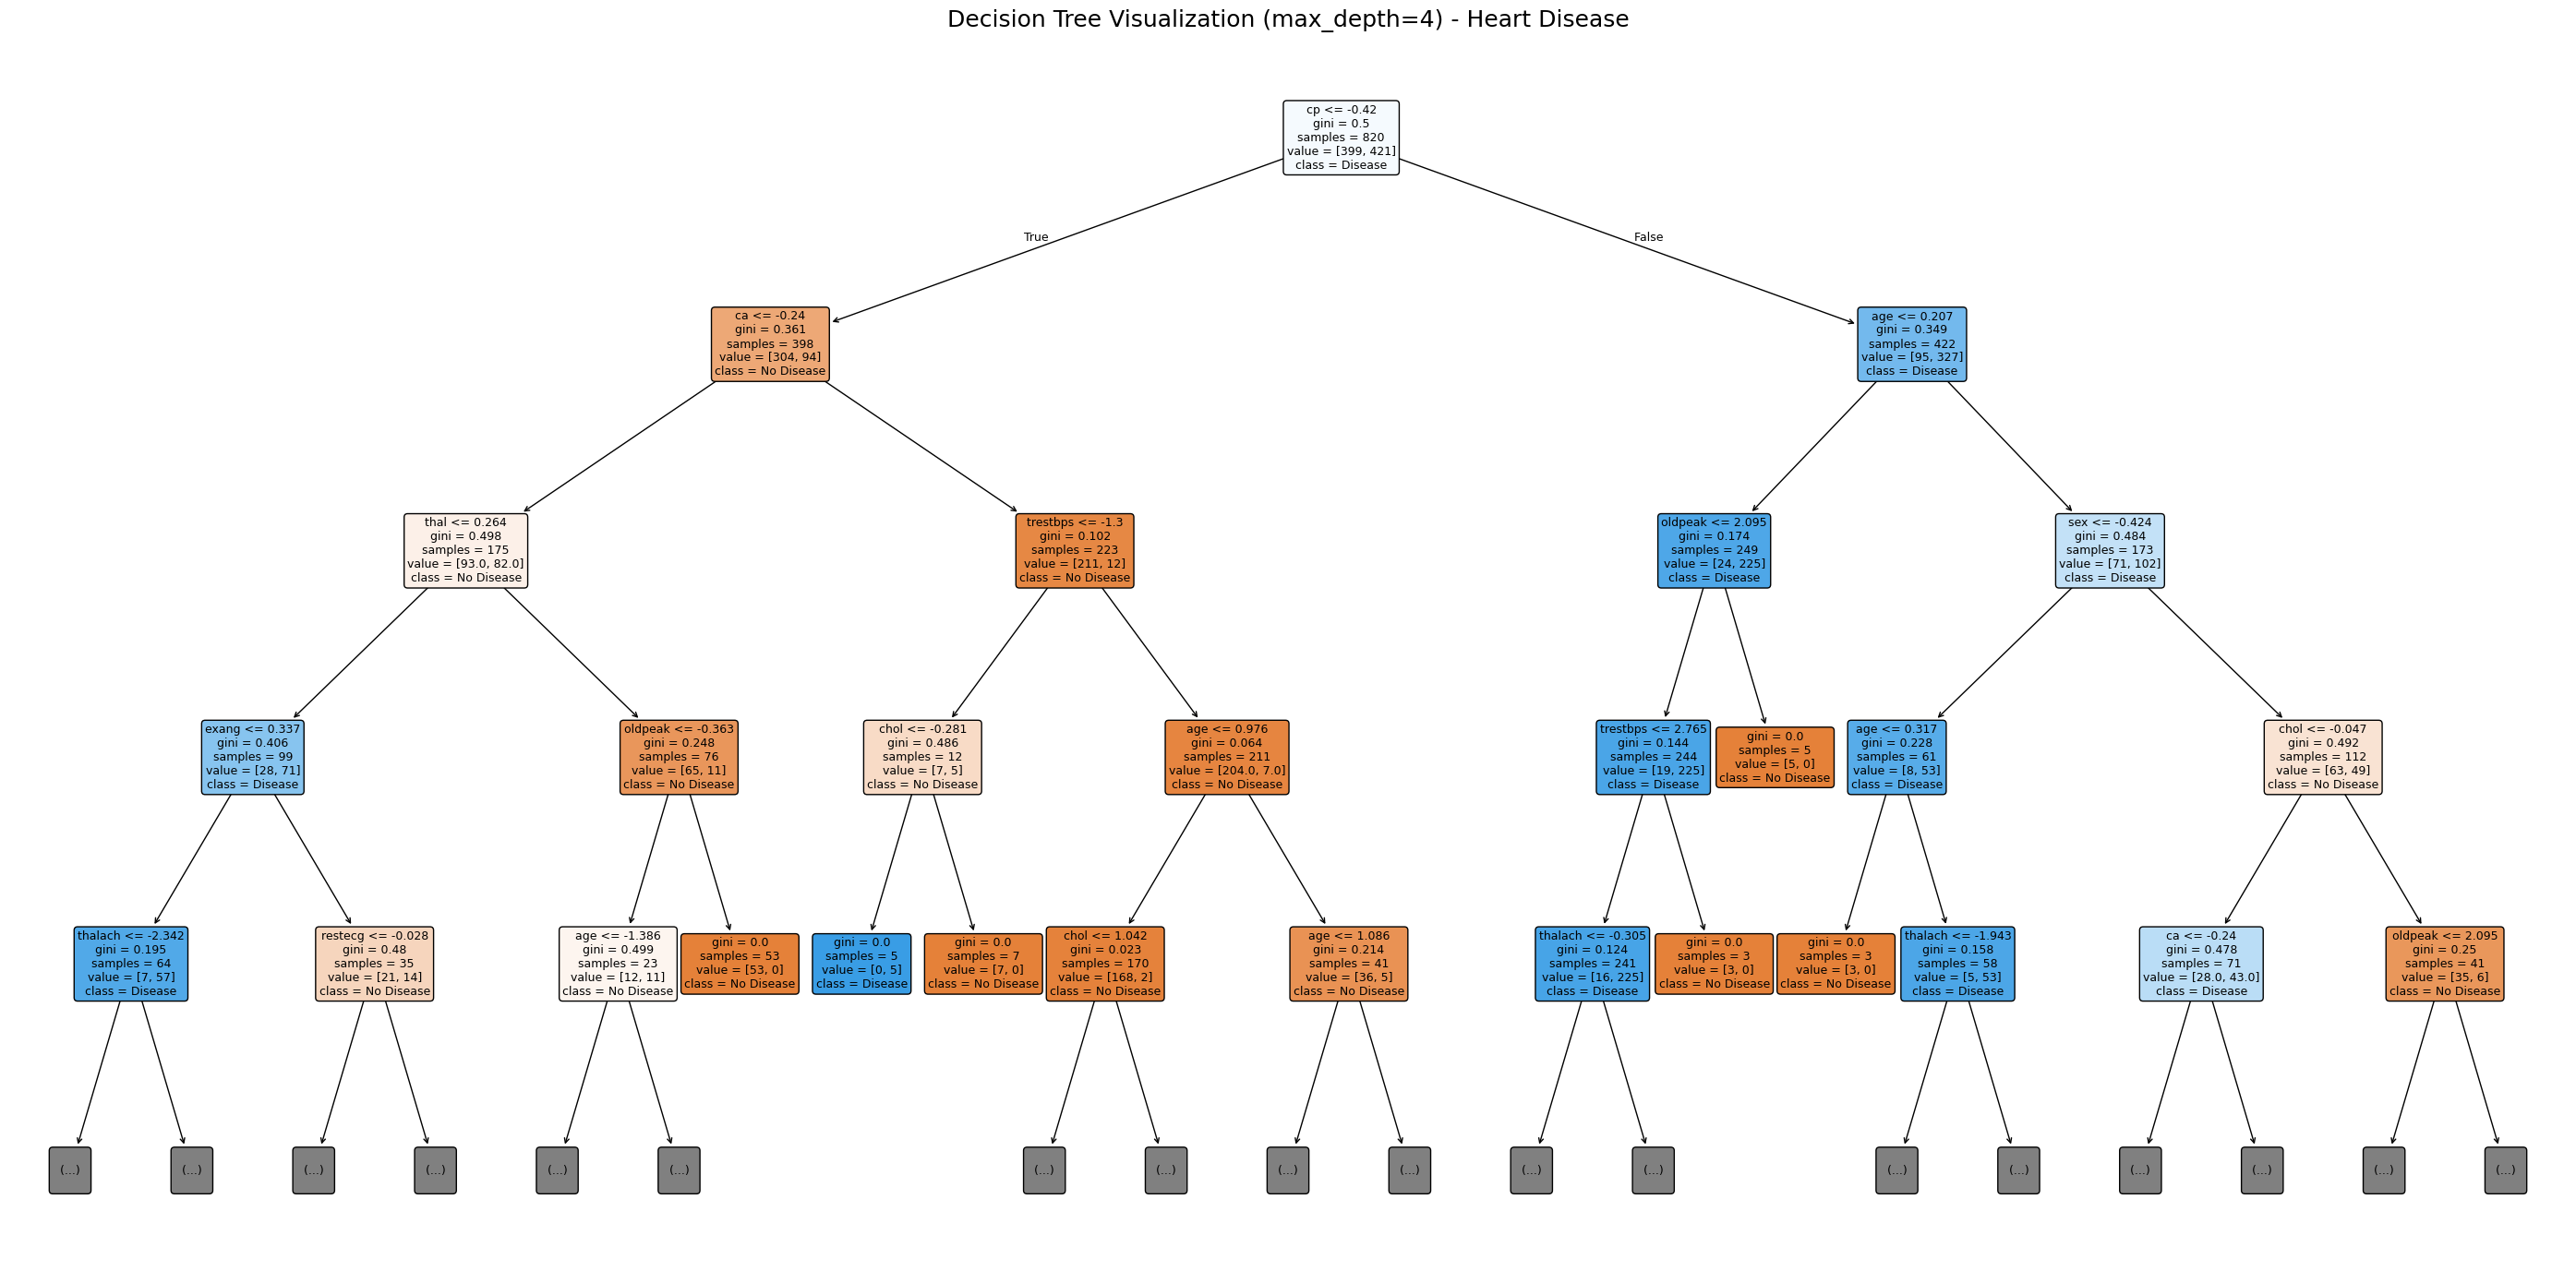

In [166]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Define class names for heart disease
target_names = ['No Disease', 'Disease']

#  Plot Decision Tree
fig, ax = plt.subplots(figsize=(28, 14))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),  # numeric heart features
    class_names=target_names,          # heart disease labels
    filled=True,
    rounded=True,
    max_depth=4,                       # only first 4 levels for clarity
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree Visualization (max_depth=4) - Heart Disease', fontsize=18)
plt.tight_layout()
plt.show()